In [1]:
import timm
import torch
import torch.nn as nn
from torchsummary import summary
from PIL import Image
from pathlib import Path
import sys
from torchvision.transforms import transforms

/home/chiendoan/miniconda3/envs/study_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ResNet18_model = timm.create_model('resnet18.a1_in1k',pretrained=True)

In [3]:
for name, module in ResNet18_model.named_modules():
    # Xét xem module đó có thuộc tính parameter không
    if hasattr(module, 'parameters'):
        is_trainable = any(param.requires_grad for param in module.parameters())
        print(f"Name: {name} - {'trainable' if is_trainable else 'not trainable'}")



Name:  - trainable
Name: conv1 - trainable
Name: bn1 - trainable
Name: act1 - not trainable
Name: maxpool - not trainable
Name: layer1 - trainable
Name: layer1.0 - trainable
Name: layer1.0.conv1 - trainable
Name: layer1.0.bn1 - trainable
Name: layer1.0.drop_block - not trainable
Name: layer1.0.act1 - not trainable
Name: layer1.0.aa - not trainable
Name: layer1.0.conv2 - trainable
Name: layer1.0.bn2 - trainable
Name: layer1.0.act2 - not trainable
Name: layer1.1 - trainable
Name: layer1.1.conv1 - trainable
Name: layer1.1.bn1 - trainable
Name: layer1.1.drop_block - not trainable
Name: layer1.1.act1 - not trainable
Name: layer1.1.aa - not trainable
Name: layer1.1.conv2 - trainable
Name: layer1.1.bn2 - trainable
Name: layer1.1.act2 - not trainable
Name: layer2 - trainable
Name: layer2.0 - trainable
Name: layer2.0.conv1 - trainable
Name: layer2.0.bn1 - trainable
Name: layer2.0.drop_block - not trainable
Name: layer2.0.act1 - not trainable
Name: layer2.0.aa - not trainable
Name: layer2.0.conv

In [4]:
summary(ResNet18_model, input_size=(3,224,224), batch_size=1, device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [1, 64, 112, 112]           9,408
       BatchNorm2d-2          [1, 64, 112, 112]             128
              ReLU-3          [1, 64, 112, 112]               0
         MaxPool2d-4            [1, 64, 56, 56]               0
            Conv2d-5            [1, 64, 56, 56]          36,864
       BatchNorm2d-6            [1, 64, 56, 56]             128
          Identity-7            [1, 64, 56, 56]               0
              ReLU-8            [1, 64, 56, 56]               0
          Identity-9            [1, 64, 56, 56]               0
           Conv2d-10            [1, 64, 56, 56]          36,864
      BatchNorm2d-11            [1, 64, 56, 56]             128
             ReLU-12            [1, 64, 56, 56]               0
       BasicBlock-13            [1, 64, 56, 56]               0
           Conv2d-14            [1, 64,

In [5]:
ROOT_DIR = Path.cwd().parent
ROOT_DIR

PosixPath('/home/chiendoan/Code_Module6/Introduce-Object-Detection-')

In [6]:
sys.path.append(str(ROOT_DIR))

In [7]:
image_path = ROOT_DIR/'data'/'twodogs.jpg'

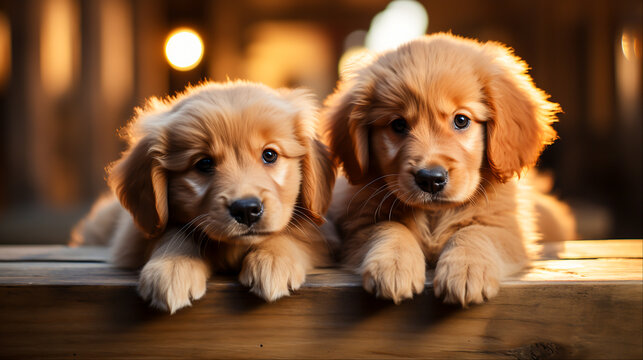

In [8]:
img = Image.open(Path(image_path))
img

In [9]:
ResNet18_model.pretrained_cfg

{'url': 'https://github.com/huggingface/pytorch-image-models/releases/download/v0.1-rsb-weights/resnet18_a1_0-d63eafa0.pth',
 'hf_hub_id': 'timm/resnet18.a1_in1k',
 'architecture': 'resnet18',
 'tag': 'a1_in1k',
 'custom_load': False,
 'input_size': (3, 224, 224),
 'test_input_size': (3, 288, 288),
 'fixed_input_size': False,
 'interpolation': 'bicubic',
 'crop_pct': 0.95,
 'test_crop_pct': 1.0,
 'crop_mode': 'center',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'num_classes': 1000,
 'pool_size': (7, 7),
 'first_conv': 'conv1',
 'classifier': 'fc',
 'license': 'apache-2.0',
 'origin_url': 'https://github.com/huggingface/pytorch-image-models',
 'paper_ids': 'arXiv:2110.00476'}

In [10]:
transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean = (0.485, 0.456, 0.406),
        std = (0.229, 0.224, 0.225)
    )
])

In [11]:
img = transformer(img)
img.shape

torch.Size([3, 360, 643])

In [12]:
_, h, w = img.shape

In [13]:
# Kích thước của 1 PATCH khi đưa vào mô hình ResNet18
Resize_transformer = transforms.Resize((224,224))
IMAGE_PATCH_INFOR = {}
PATCH_SIZE = 280
step = 20
Patch_cout = 0
for y in range(0, h - PATCH_SIZE + 1, step):
    for x in range(0, w - PATCH_SIZE + 1, step):
        img_patch = img[:, y: y+PATCH_SIZE, x: x+ PATCH_SIZE]
        img_patch = Resize_transformer(img_patch)
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        ResNet18_model.to(device)
        with torch.no_grad():
            ResNet18_model.eval()
            # Thêm chiều batch vào shape của ảnh
            img_patch = img_patch.unsqueeze(0)
            img_patch = img_patch.to(device)
            y_pred = nn.functional.softmax(ResNet18_model(img_patch),dim=1)
            idx = torch.argmax(y_pred, dim = 1)
            score = y_pred[:, idx]
            IMAGE_PATCH_INFOR.update({
                f'img{Patch_cout}':
                {'locate': (x, y, x + PATCH_SIZE, y + PATCH_SIZE),
                'confidence_score': score.item()
                }
            })
            Patch_cout +=1
        

In [14]:
IMAGE_PATCH_INFOR_SORTED = sorted(IMAGE_PATCH_INFOR.items(),key= lambda x: x[1]['confidence_score'], reverse=True)

In [15]:
IMAGE_PATCH_INFOR_SORTED

[('img51',
  {'locate': (260, 40, 540, 320), 'confidence_score': 0.9932934045791626}),
 ('img32',
  {'locate': (260, 20, 540, 300), 'confidence_score': 0.9920071363449097}),
 ('img31',
  {'locate': (240, 20, 520, 300), 'confidence_score': 0.9917718768119812}),
 ('img13',
  {'locate': (260, 0, 540, 280), 'confidence_score': 0.9911989569664001}),
 ('img23',
  {'locate': (80, 20, 360, 300), 'confidence_score': 0.9908677339553833}),
 ('img50',
  {'locate': (240, 40, 520, 320), 'confidence_score': 0.9896185994148254}),
 ('img12',
  {'locate': (240, 0, 520, 280), 'confidence_score': 0.9890052676200867}),
 ('img30',
  {'locate': (220, 20, 500, 300), 'confidence_score': 0.9885751605033875}),
 ('img21',
  {'locate': (40, 20, 320, 300), 'confidence_score': 0.988109290599823}),
 ('img91',
  {'locate': (300, 80, 580, 360), 'confidence_score': 0.9876184463500977}),
 ('img14',
  {'locate': (280, 0, 560, 280), 'confidence_score': 0.986825168132782}),
 ('img33',
  {'locate': (280, 20, 560, 300), 'conf

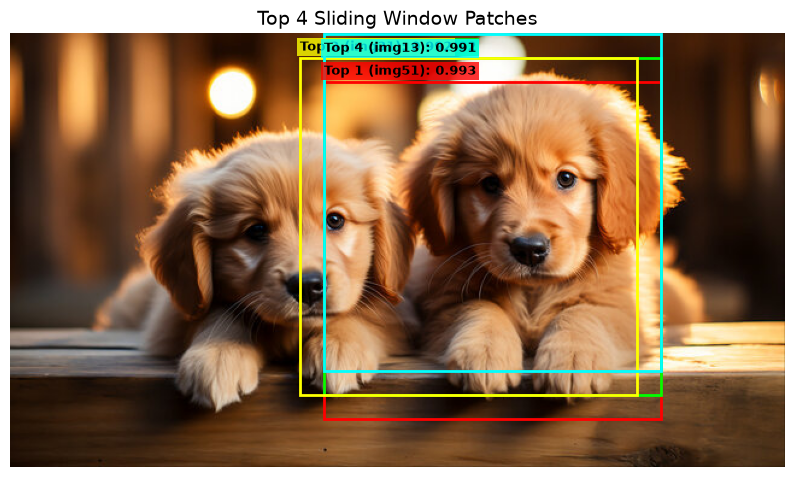

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

orig_img = Image.open(image_path)
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(orig_img)

# Số lượng patch muốn hiển thị
TOP_K = 4
colors = ['red', 'lime', 'yellow', 'cyan', 'magenta','darkcyan','indigo']

for i in range(min(TOP_K, len(IMAGE_PATCH_INFOR_SORTED))):
    patch_name, patch_info = IMAGE_PATCH_INFOR_SORTED[i]
    x1, y1, x2, y2 = patch_info['locate']
    score = patch_info['confidence_score']
    w = x2 - x1
    h = y2 - y1
    
    color = colors[i % len(colors)]
    
    # Vẽ box
    rect = patches.Rectangle(
        (x1, y1), w, h, 
        linewidth=2, 
        edgecolor=color, 
        facecolor='none'
    )
    ax.add_patch(rect)
    
    # Hiển thị score
    ax.text(
        x1, 
        y1 - 6 if y1 - 6 > 10 else y1 + 15, 
        f"Top {i+1} ({patch_name}): {score:.3f}", 
        color='black', 
        fontsize=9, 
        fontweight='bold',
        bbox=dict(facecolor=color, alpha=0.8, edgecolor='none', pad=2)
    )

plt.title(f"Top {TOP_K} Sliding Window Patches", fontsize=14)
plt.axis('off')
plt.show()


# Compute IoU - intersection over union 

In [17]:
def Compute_IoU(
    x11: int = None,
    y11: int = None,
    x12: int = None,
    y12: int = None,
    x21: int = None,
    y21: int = None,
    x22: int = None,
    y22: int = None,
)-> float:
    '''
    (x11, y11, x12, y12) - Tọa độ góc trái trên, góc phải dưới của bbx1
    (x21, y21, x22, y22) - Tọa độ góc trái trên, góc phải dưới của bbx2
    '''
    # TỌA ĐỘ GÓC TRÁI TRÊN CỦA INTERSECTION
    x_left_top_inter = max(x11, x21)
    y_left_top_inter = max(y11, y21)

    x_right_down_inter = min(x12, x22)
    y_right_down_inter = min(y12, y22)

    Area_intersection = max(0, x_right_down_inter - x_left_top_inter) *max(0, y_right_down_inter - y_left_top_inter)

    Area_Union = (x12-x11)*(y12-y11) + (x22 - x21)*(y22 -y21) - Area_intersection

    IoU = Area_intersection/Area_Union
    return IoU

In [18]:
x11, y11, x12, y12 = IMAGE_PATCH_INFOR_SORTED[0][1]['locate']

In [19]:
x21, y21, x22, y22 = IMAGE_PATCH_INFOR_SORTED[3][1]['locate']

In [20]:
Compute_IoU(x11, y11, x12, y12, x21, y21, x22, y22)

0.75

In [21]:
x21, y21, x22, y22 = IMAGE_PATCH_INFOR_SORTED[1][1]['locate']

In [22]:
Compute_IoU(x11, y11, x12, y12, x21, y21, x22, y22)

0.8666666666666667

In [23]:
# Tập GIỮ LẠI CANDIDATE - BOUNDING_BOX - tập ứng viên BOUDING BOX
KEEP = [IMAGE_PATCH_INFOR_SORTED.pop(0)]
# thresshold - Ngưỡng để loại bỏ những bbx có sự chồng lấn vượt quá thresshold
threshold = 0.35
while len(IMAGE_PATCH_INFOR_SORTED):
    # List Index cần xóa
    list_del = []
    for i in range (len(IMAGE_PATCH_INFOR_SORTED)):
        IoU = Compute_IoU(*KEEP[-1][1]['locate'], *IMAGE_PATCH_INFOR_SORTED[i][1]['locate'])
        if  IoU >= threshold:
            list_del.append(i)
    # Xóa bbx thỏa mãn > threshold
    for i in sorted(list_del,reverse=True):
        del IMAGE_PATCH_INFOR_SORTED[i]
    # Xắp xếp lại IMAGE_PATCH_INFOR_SORTED sau khi xóa bbx không thoả mãn
    IMAGE_PATCH_INFOR_SORTED = sorted(IMAGE_PATCH_INFOR_SORTED,key= lambda x: x[1]['confidence_score'], reverse=True)
    if len(IMAGE_PATCH_INFOR_SORTED):
        KEEP.append(IMAGE_PATCH_INFOR_SORTED.pop(0))

In [24]:
KEEP

[('img51',
  {'locate': (260, 40, 540, 320), 'confidence_score': 0.9932934045791626}),
 ('img23',
  {'locate': (80, 20, 360, 300), 'confidence_score': 0.9908677339553833})]

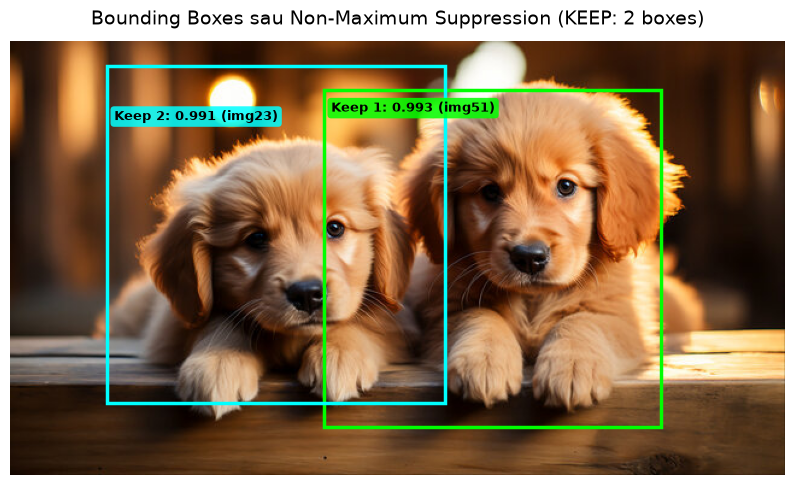

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Mở lại ảnh gốc
orig_img = Image.open(image_path)
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(orig_img)

# Bảng màu hiển thị cho từng box
colors = ['lime', 'cyan', 'yellow', 'magenta', 'red', 'orange']

for i, (patch_name, patch_info) in enumerate(KEEP):
    x1, y1, x2, y2 = patch_info['locate']
    score = patch_info['confidence_score']
    w = x2 - x1
    h = y2 - y1
    
    color = colors[i % len(colors)]
    
    # Vẽ bounding box
    rect = patches.Rectangle(
        (x1, y1), w, h, 
        linewidth=2.5, 
        edgecolor=color, 
        facecolor='none'
    )
    ax.add_patch(rect)
    
    # Đặt vị trí nhãn so le theo trục y để nhãn không bị đè lên nhau nếu các box liền kề
    y_text = y1 + 18 if i % 2 == 0 else y1 + 45
    
    # Hiển thị thông tin patch & confidence score
    label = f"Keep {i+1}: {score:.3f} ({patch_name})"
    ax.text(
        x1 + 6, 
        y_text, 
        label, 
        color='black', 
        fontsize=9, 
        fontweight='bold',
        bbox=dict(facecolor=color, alpha=0.85, edgecolor='none', boxstyle='round,pad=0.3')
    )

plt.title(f"Bounding Boxes sau Non-Maximum Suppression (KEEP: {len(KEEP)} boxes)", fontsize=14, pad=12)
plt.axis('off')
plt.show()
